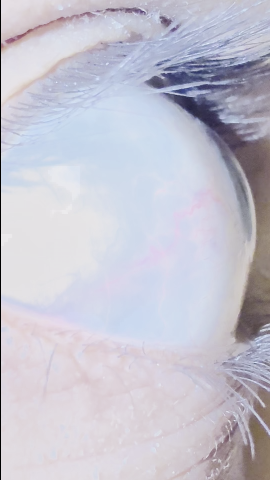

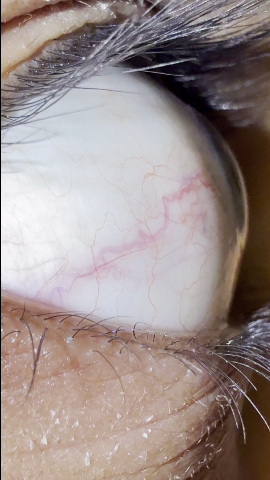

Resolution: (1920, 1080, 3), FPS: 29.97685185185185, Total Frames: 259.0, duration: 8.64 seconds


In [28]:
import cv2
import numpy as np

from PIL import Image
from IPython.display import display

import skimage as ski


def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return

video_source = r"uploads\IMG_1735.MOV"  # Change this to your video file path or camera index

cap = cv2.VideoCapture(video_source)
_ret, cap_1 = cap.read()  # Read the first frame to check if the video is valid

# get frame number 32
cap.set(cv2.CAP_PROP_POS_FRAMES, 32)
_ret, cap_32 = cap.read()

show(cap_1)
show(cap_32)
print(f"Resolution: {cap_1.shape}, FPS: {cap.get(cv2.CAP_PROP_FPS)}, Total Frames: {cap.get(cv2.CAP_PROP_FRAME_COUNT)}, duration: {cap.get(cv2.CAP_PROP_FRAME_COUNT) / cap.get(cv2.CAP_PROP_FPS)} seconds")

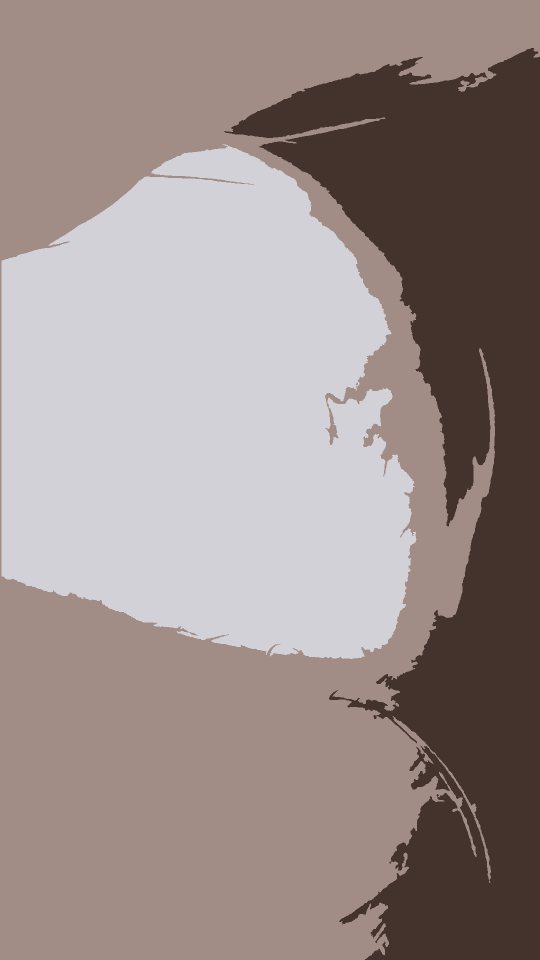

In [29]:
cap_32_seg = ski.segmentation.slic(cap_32, n_segments=4, compactness=5)
show(ski.color.label2rgb(cap_32_seg, cap_32, kind='avg'), .5)

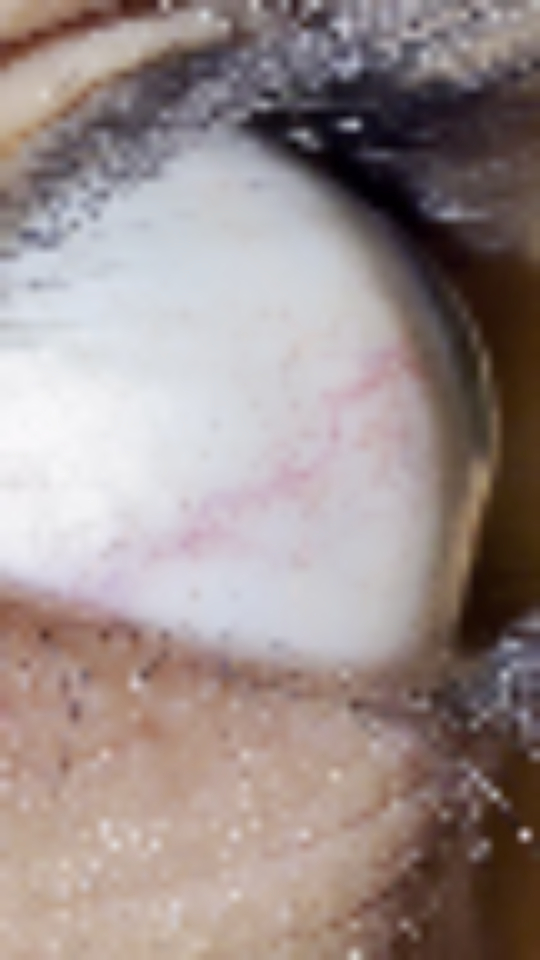

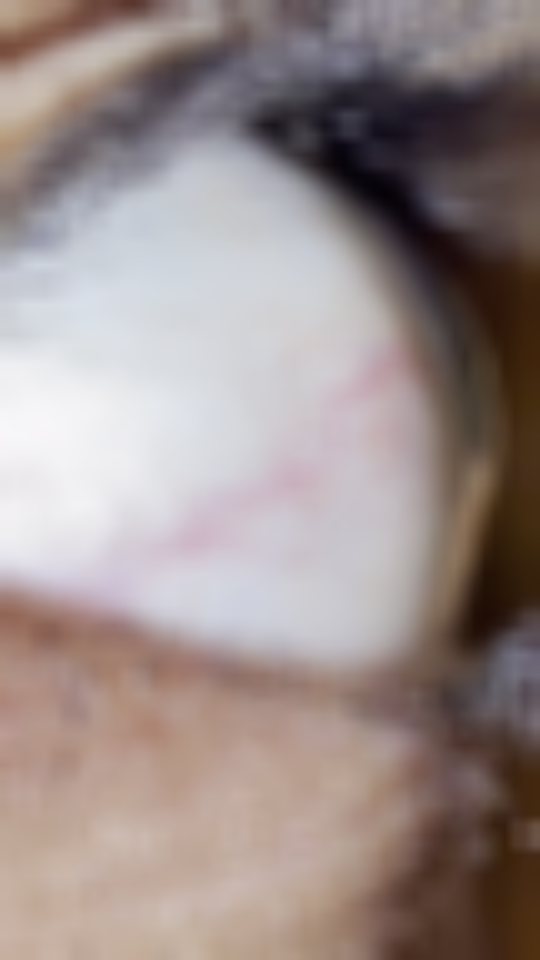

In [51]:
import numpy as np

# cap_32_blur = cv2.blur(cap_32, (51, 51))
cap_32_lowRes = cv2.resize(cap_32, (0, 0), fx=0.05, fy=0.05)
#expand the low res image back to original size for display wirhout losing the blur effect


# cap_32_gaussian = cv2.GaussianBlur(cap_32_blur, (3,3), 0)
cap_32_gaussian_lowRes = cv2.GaussianBlur(cap_32_lowRes, (3,3), 3)
cap_32_lowRes = cv2.resize(cap_32_lowRes, (cap_32.shape[1], cap_32.shape[0]))

cap_32_gaussian_lowRes = cv2.resize(cap_32_gaussian_lowRes, (cap_32.shape[1], cap_32.shape[0]))
# cap_32 = cap_32_blur.astype(np.float32)
# show(cap_32_blur, scale_factor=.5)
show(cap_32_lowRes, scale_factor=.5)
# show(cap_32_gaussian, scale_factor=.5)
show(cap_32_gaussian_lowRes, scale_factor=.5)
# cap_32_bilat = cv2.bilateralFilter(cap_32_blur, d=5, sigmaColor=500, sigmaSpace=1)
# calculate the difference between bilateral and original
# cap_32_diff = cv2.absdiff(cap_32, cap_32_bilat)
# print(f"Mean: {np.mean(cap_32_diff)}, Std: {np.std(cap_32_diff)}, Max: {np.max(cap_32_diff)}, Min: {np.min(cap_32_diff)}")
# cv2.imshow("Gaussian", cap_32_gaussian)
# cv2.imshow("Bilateral", cap_32_bilat)
# display(Image.fromarray(cv2.cvtColor(cap_32_gaussian.astype(np.uint8), cv2.COLOR_BGR2RGB))))
# scale down the bilateral image for display
# cap_32_bilat_display = cv2.resize(cap_32_bilat, (0, 0), fx=0.25, fy=0.25)
# display(Image.fromarray(cv2.cvtColor(cap_32_bilat_display.astype(np.uint8), cv2.COLOR_BGR2RGB)))


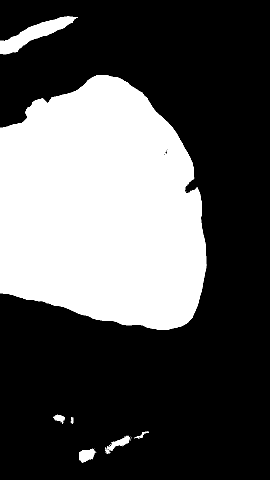

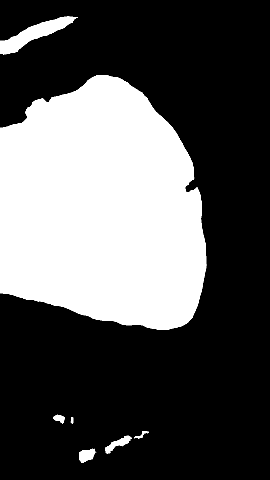

In [52]:


cap_32_hsv = cv2.cvtColor(cap_32_gaussian_lowRes, cv2.COLOR_BGR2HSV)
# show(cap_32_bilat)
# hsv_gaussian = cv2.GaussianBlur(cap_32_hsv, (15,15), 0)
# show(hsv_gaussian[:,:,1])
thresh_hsv = cv2.inRange(cap_32_hsv, (0, 1, 180), (180, 35, 255))
close_hsv = cv2.morphologyEx(thresh_hsv, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
show(thresh_hsv)
show(close_hsv)
# get only 1 channel of the hsv image
# cap_32_hsv[:, :, 1].shape
# cv2.cvtColor(cap_32_hsv[1], cv2.COLOR_GRAY2RGB).shape


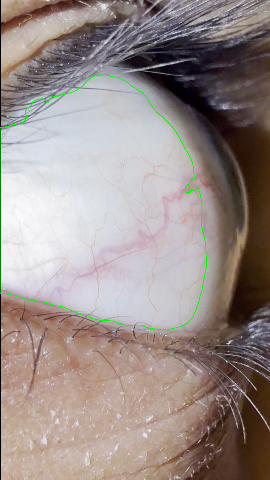

: 

In [ ]:
def draw_contour(largest_contour):
    contour_img = cap_32.copy()
    cv2.drawContours(contour_img, [largest_contour], -1, (0, 255, 0), 2)
    show(contour_img)

# select the largetst contour in the thresh_hsv image
contours, _ = cv2.findContours(thresh_hsv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)


draw_contour(largest_contour)

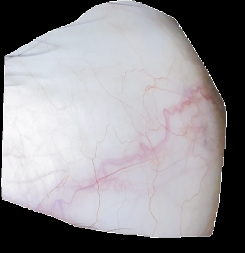

In [8]:
roi = cv2.imread("IMG_1735_F32.png")
show(roi)
# cv2.imwrite("IMG_1735_F32.png", cap_32)


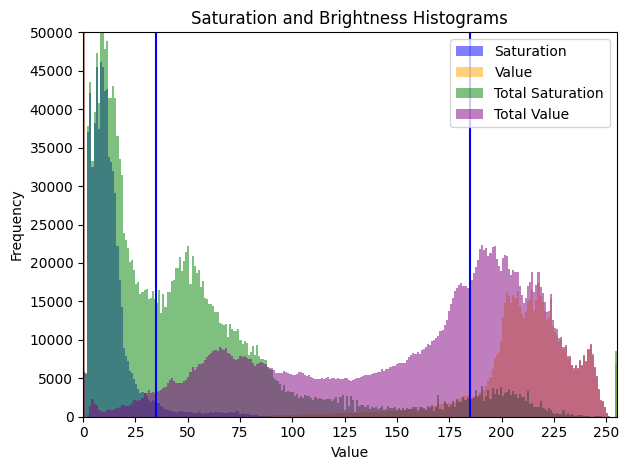

In [60]:
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

cap_32_hsv = cv2.cvtColor(cap_32, cv2.COLOR_BGR2HSV)
cap_32_equalized = cv2.equalizeHist(cap_32_hsv[:, :, 2])
import matplotlib.pyplot as plt

# OpenCV HSV ranges: H=[0,179], S=[0,255], V=[0,255]
h = roi_hsv[:, :, 0].astype(np.float32) / 179.0
s = roi_hsv[:, :, 1].astype(np.float32) # / 255.0
v = roi_hsv[:, :, 2].astype(np.float32) # / 255.0

cap_h = cap_32_hsv[:, :, 0].astype(np.float32) / 179.0
cap_s = cap_32_hsv[:, :, 1].astype(np.float32) #
cap_v = cap_32_hsv[:, :, 2].astype(np.float32) #

plt.hist(s.ravel(), bins=256, range=(0, 255), color='blue', alpha=0.5, label='Saturation')
plt.hist(v.ravel(), bins=256, range=(0, 255), color='orange', alpha=0.5, label='Value')

plt.hist(cap_s.ravel(), bins=256, range=(0, 255), color='green', alpha=0.5, label='Total Saturation')
plt.hist(cap_v.ravel(), bins=256, range=(0, 255), color='purple', alpha=0.5, label='Total Value')

# plt.hist(h.ravel(), bins=180, range=(0, 1), color='green', alpha=0.5, label='Hue')
plt.title("Saturation and Brightness Histograms")
plt.xlabel("Value")
plt.ylabel("Frequency")
# set y-axis scale 1- 50000
# plt.yticks(np.arange(0, 50001, 5000))
plt.ylim(0, 50000)
plt.yticks(np.arange(0, 50001, 5000))
plt.xlim(0, 255)
plt.xticks(np.arange(0, 256, 25))
plt.vlines(x=[35, 185], ymax=50000, ymin=0, colors='blue')
plt.legend()
# plt.savefig("histograms.png")
# plt.close()


plt.tight_layout()



# show(roi_hsv[:,:,1])

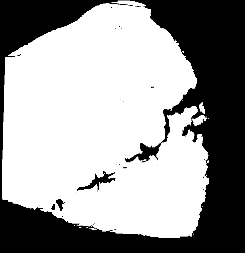

In [34]:
roi_hsv_thresh = cv2.inRange(roi_hsv, (0, 1, 180), (180, 25, 252))
show(roi_hsv_thresh)

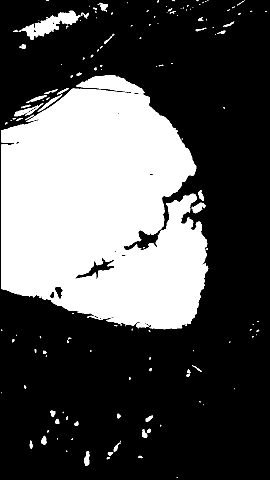

In [ ]:
# clean speckles in thresh_hsv using morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
thresh_hsv_ex = cv2.morphologyEx(thresh_hsv, cv2.MORPH_OPEN, kernel)
show(thresh_hsv_ex)

In [53]:
cv2.useOptimized()

True